In [53]:
!pip install seaborn
!pip install  scikit-learn

  Using cached scikit_learn-1.6.1-cp313-cp313-macosx_12_0_arm64.whl.metadata (31 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.6.1-cp313-cp313-macosx_12_0_arm64.whl (11.1 MB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached threadpoolctl-3.5.0-py3-none-any.whl (18 kB)


In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from sklearn.preprocessing import StandardScaler


In [2]:
def load_data(directory):
    data = []
    print( os.listdir(directory))
    files = glob.glob(directory + '/**/*.json', recursive=True)
    for filename in files:

        if "obj.json" in filename:
            with open(filename, 'r') as file:
                data.append(json.load(file))
    return data


In [67]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribution(data, title, y_label, x_label,  kde=True):
    color = np.random.choice(["blue", "green", "purple", "orange", "brown", "pink", "red", "yellow"])
    sns.histplot(data, kde=kde, color=color)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()


def plot_shapes_distribution(shapes):
    df_shapes = pd.DataFrame({"shape": shapes})
    plt.figure(figsize=(8, 6))
    sns.countplot(x="shape", data=df_shapes, palette="viridis")
    plt.title("Distribution of Shapes")
    plt.xlabel("Shape")
    plt.ylabel("Count")
    plt.show()
    
def extract_world_features(data):
    # floor
    friction_static = []
    friction_dynamic = []
    friction_spin = []
    # floor_rgba_r = []
    # floor_rgba_g = []
    # floor_rgba_b = []
    floor_speculars = []
    floor_shininesses = []

    # camera
    camera_lookat_x = []
    camera_lookat_y = []
    camera_lookat_z = []
    camera_distance = []
    camera_azimuth = []
    camera_elevation = []

    # lights
    lights_pos_x = []
    lights_pos_y = []
    lights_pos_z = []
    lights_diffuse_r = []
    lights_diffuse_g = []
    lights_diffuse_b = []
    lights_specular_r = []
    lights_specular_g = []
    lights_specular_b = []
    lights_cutoff = []
    lights_directional = []
    
    for item in data:
        world = item.get("world", {})
        floor = world.get("floor", {})
        camera = world.get("camera", {})
        lights = world.get("lights", [])
        
        # floor friction
        friction_str = floor.get("friction", "0 0 0")
        frictions = friction_str.split()
        friction_static.append(float(frictions[0]))
        friction_dynamic.append(float(frictions[1]))
        friction_spin.append(float(frictions[2]))

        # rgba_str = floor.get("rgba", "0 0 0 1")
        # rgba = [float(c) for c in rgba_str.split()]
        # floor_rgba_r.append(rgba[0])
        # floor_rgba_g.append(rgba[1])
        # floor_rgba_b.append(rgba[2])

        # specular and shininess
        floor_speculars.append(float(floor.get("specular", 0)))
        floor_shininesses.append(float(floor.get("shininess", 0)))


        lookat = camera.get("lookat", [0, 0, 0])
        camera_lookat_x.append(float(lookat[0]) if len(lookat) > 0 else 0)
        camera_lookat_y.append(float(lookat[1]) if len(lookat) > 1 else 0)
        camera_lookat_z.append(float(lookat[2]) if len(lookat) > 2 else 0)
        camera_distance.append(float(camera.get("distance", 0)))
        camera_azimuth.append(float(camera.get("azimuth", 0)))
        camera_elevation.append(float(camera.get("elevation", 0)))

        for light in lights:
            pos = light.get("pos", [0, 0, 0])
            lights_pos_x.append(float(pos[0]) if len(pos) > 0 else 0)
            lights_pos_y.append(float(pos[1]) if len(pos) > 1 else 0)
            lights_pos_z.append(float(pos[2]) if len(pos) > 2 else 0)

            diffuse_str = light.get("diffuse", "0 0 0")
            diffuse = [float(c) for c in diffuse_str.split()]
            lights_diffuse_r.append(diffuse[0] if len(diffuse) > 0 else 0)
            lights_diffuse_g.append(diffuse[1] if len(diffuse) > 1 else 0)
            lights_diffuse_b.append(diffuse[2] if len(diffuse) > 2 else 0)

            # specular_str = light.get("specular", "0 0 0")
            # specular = [float(c) for c in specular_str.split()]
            # lights_specular_r.append(specular[0] if len(specular) > 0 else 0)
            # lights_specular_g.append(specular[1] if len(specular) > 1 else 0)
            # lights_specular_b.append(specular[2] if len(specular) > 2 else 0)

            lights_cutoff.append(float(light.get("cutoff", 0)))
            # lights_directional.append(bool(light.get("directional", False)))


    return {
        "friction_static": friction_static,
        "friction_dynamic": friction_dynamic,
        "friction_spin": friction_spin,
        # "floor_rgba_r": floor_rgba_r,
        # "floor_rgba_g": floor_rgba_g,
        # "floor_rgba_b": floor_rgba_b,
        "floor_speculars": floor_speculars,
        "floor_shininesses": floor_shininesses,

        "camera_lookat_x": camera_lookat_x,
        "camera_lookat_y": camera_lookat_y,
        "camera_lookat_z": camera_lookat_z,
        "camera_distance": camera_distance,
        "camera_azimuth": camera_azimuth,
        "camera_elevation": camera_elevation,

        "lights_pos_x": lights_pos_x,
        "lights_pos_y": lights_pos_y,
        "lights_pos_z": lights_pos_z,
        # "lights_diffuse_r": lights_diffuse_r,
        # "lights_diffuse_g": lights_diffuse_g,
        # "lights_diffuse_b": lights_diffuse_b,
        # "lights_specular_r": lights_specular_r,
        # "lights_specular_g": lights_specular_g,
        # "lights_specular_b": lights_specular_b,
        "lights_cutoff": lights_cutoff,
    }



def extract_features(data):
    masses = []
    velocities = []
    accelerations = []
    angular_velocities = []
    angular_accelerations = []
    frictions = []
    friction_static = []
    friction_dynamic = []
    friction_spin = []
    densities = []
    elasticities = []
    shapes = []

    prev_info = {}

    for item in data:
        objects = item.get("objects", [])
        
        frames = item.get("frames", [])
        for frame in frames:
            time_current = frame['time']
    
            for obj_id, obj in frame['objects'].items():
                #  current velocity magnitude
                current_velocity = np.linalg.norm(obj.get('velocity', []))
                # print(current_velocity)
                velocities.append(current_velocity)
                # current angular velocity magnitude
                current_ang_vel = np.linalg.norm(obj.get('angular_velocity', []))
                angular_velocities.append(current_ang_vel)
                
                #  acceleration if previous data exists for this object
                if obj_id in prev_info:
                    prev_time, prev_vel, prev_ang_vel = prev_info[obj_id]
                    dt = time_current - prev_time
                    # if dt > 0:
                    if current_velocity >  np.linalg.norm(prev_vel):
                        acc = np.linalg.norm((current_velocity - prev_vel) / dt)
                        ang_acc = np.linalg.norm((current_ang_vel - prev_ang_vel) / dt)
                        accelerations.append(acc)
                        angular_accelerations.append(ang_acc)
                    else:
                        accelerations.append(0)
                        angular_accelerations.append(0)
                else:
                    accelerations.append(0)
                    angular_accelerations.append(0)
                    
                # Update previous info for this object
                prev_info[obj_id] = (time_current, current_velocity, current_ang_vel)
            
            for obj in objects:
                masses.append(obj.get('mass'))

                friction_str = obj.get("friction", "0 0 0")
                frictions = friction_str.split(' ')
                friction_static.append(float(frictions[0]))
                friction_dynamic.append(float(frictions[1]))
                friction_spin.append(float(frictions[2]))
                
                densities.append(obj.get('density'))
                elasticities.append(obj.get('elasticity'))
                shapes.append(obj.get('shape'))


    return {
        "masses": masses, 
        "velocities": velocities, # m/s
        "accelerations": accelerations,
        "angular_velocities": angular_velocities,
        "angular_accelerations": angular_accelerations,
        "friction_static": friction_static,
        "friction_dynamic": friction_dynamic,
        "friction_spin": friction_spin,
        "densities": densities,
        "elasticities": elasticities,
        "shapes": shapes,
    }        
    # return (masses, velocities, accelerations, angular_velocities,
    #         angular_accelerations, frictions, densities, elasticities)


In [68]:
directory = 'generated'
data = load_data(directory)
# datas

# masses, velocities, accelerations, frictions, densities, elasticities = extract_features(data)



['135', '307', '61', '95', '338', '300', '132', '59', '92', '66', '336', '104', '309', '50', '68', '103', '331', '57', '168', '391', '365', '157', '150', '362', '396', '159', '32', '166', '354', '192', '398', '35', '195', '353', '161', '330', '102', '69', '56', '105', '337', '51', '308', '58', '133', '301', '67', '93', '306', '134', '94', '339', '60', '399', '34', '160', '352', '194', '33', '158', '193', '355', '167', '397', '363', '151', '169', '156', '364', '390', '216', '440', '229', '447', '211', '478', '227', '471', '485', '218', '.DS_Store', '482', '476', '220', '449', '280', '422', '274', '273', '425', '287', '413', '245', '289', '242', '414', '477', '221', '483', '448', '484', '226', '470', '219', '446', '210', '479', '217', '441', '228', '288', '243', '415', '412', '244', '286', '272', '424', '423', '275', '281', '257', '401', '268', '406', '250', '439', '292', '266', '430', '259', '437', '261', '295', '408', '463', '235', '497', '490', '232', '464', '499', '452', '204', '203'

### Floor friction - coefficient [0,1]

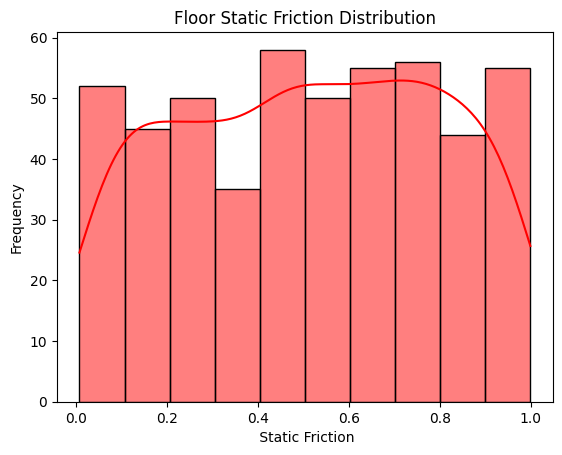

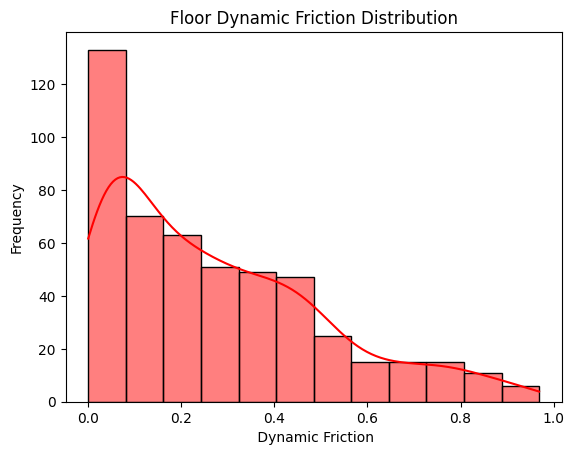

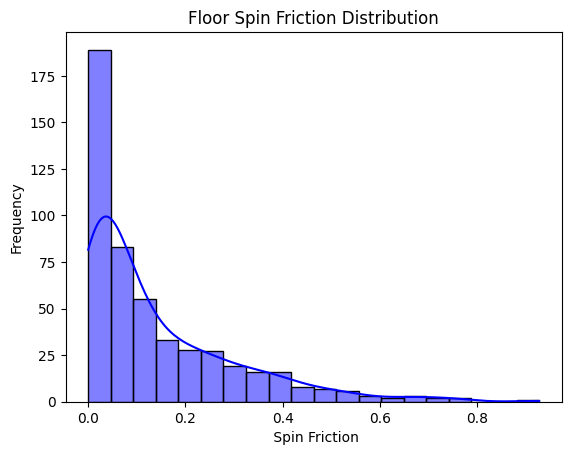

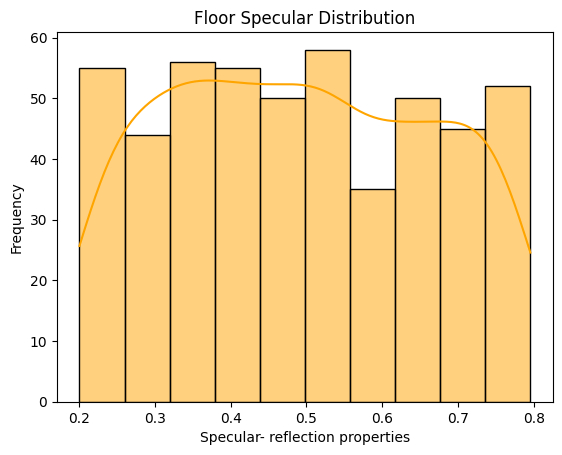

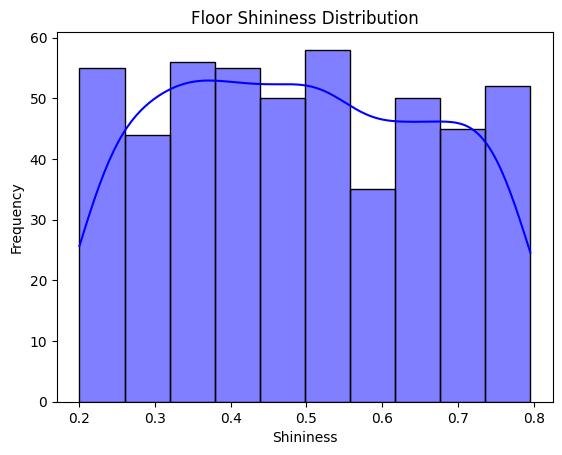

In [69]:
world_features = extract_world_features(data)

plot_distribution(world_features["friction_static"], "Floor Static Friction Distribution", "Frequency", " Static Friction")
plot_distribution(world_features["friction_dynamic"], "Floor Dynamic Friction Distribution", "Frequency", " Dynamic Friction")
plot_distribution(world_features["friction_spin"], "Floor Spin Friction Distribution", "Frequency", " Spin Friction")

plot_distribution(world_features["floor_speculars"], "Floor Specular Distribution", "Frequency", "Specular- reflection properties")
plot_distribution(world_features["floor_shininesses"], "Floor Shininess Distribution", "Frequency", "Shininess")



### Camera

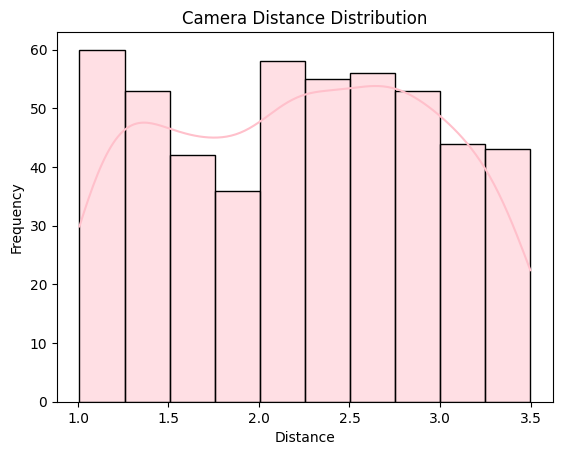

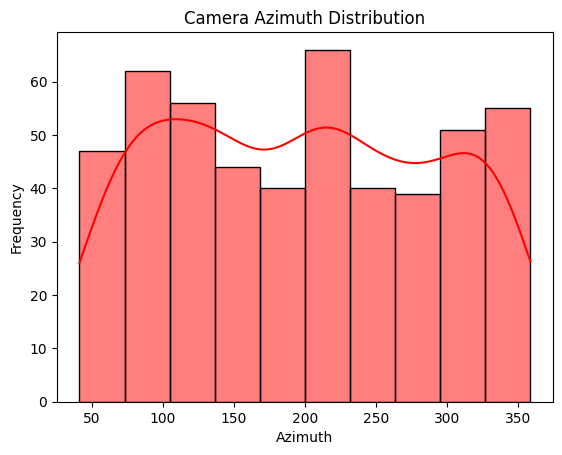

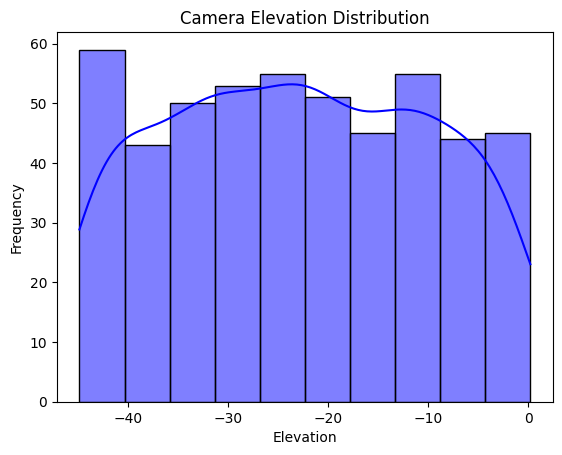

In [70]:
# distance - (m) meters
# azimuth - degrees [0, 360]
# elevation  degrees (°),  [-90°, 90°]
plot_distribution(world_features["camera_distance"], "Camera Distance Distribution", "Frequency", "Distance")
plot_distribution(world_features["camera_azimuth"], "Camera Azimuth Distribution", "Frequency", "Azimuth")
plot_distribution(world_features["camera_elevation"], "Camera Elevation Distribution", "Frequency", "Elevation")


### Lights 

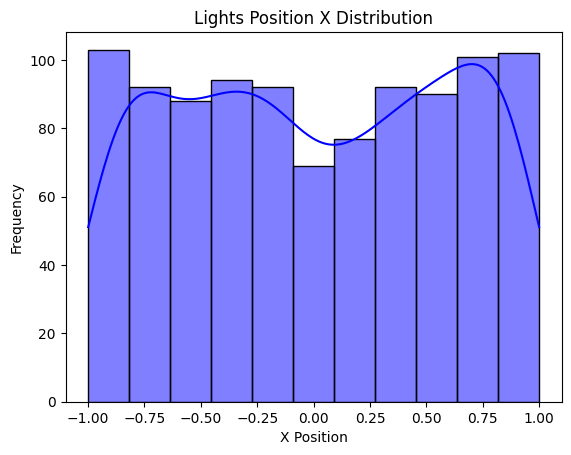

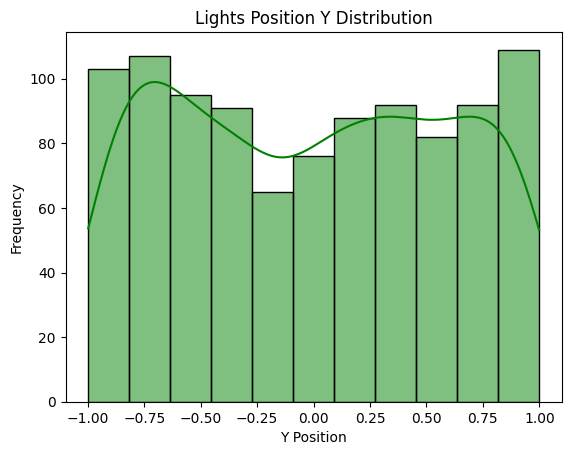

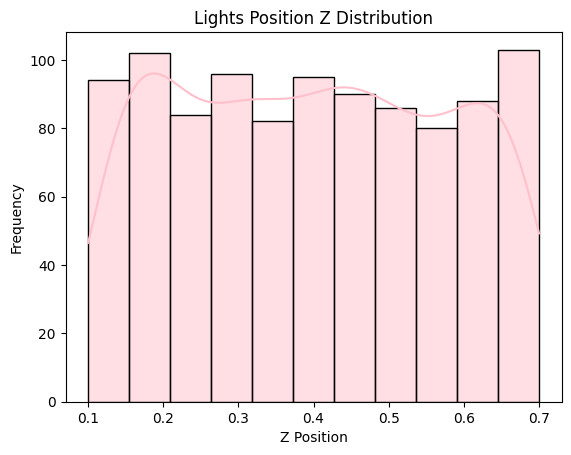

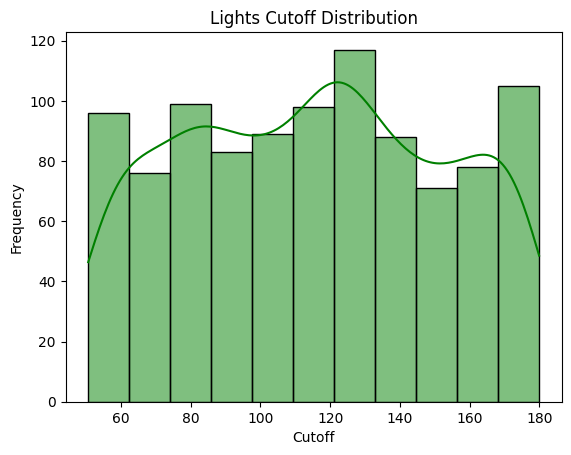

In [121]:
# meters relative to the world coordinate system
plot_distribution(world_features["lights_pos_x"], "Lights Position X Distribution", "Frequency", "X Position")
plot_distribution(world_features["lights_pos_y"], "Lights Position Y Distribution", "Frequency", "Y Position")
plot_distribution(world_features["lights_pos_z"], "Lights Position Z Distribution", "Frequency", "Z Position")
# plot_distribution(world_features["lights_diffuse_r"], "Lights Diffuse Red Distribution", "Frequency", "Diffuse R")
# plot_distribution(world_features["lights_diffuse_g"], "Lights Diffuse Green Distribution", "Frequency", "Diffuse G")
# plot_distribution(world_features["lights_diffuse_b"], "Lights Diffuse Blue Distribution", "Frequency", "Diffuse B")
# plot_distribution(world_features["lights_specular_r"], "Lights Specular Red Distribution", "Frequency", "Specular R")
# plot_distribution(world_features["lights_specular_g"], "Lights Specular Green Distribution", "Frequency", "Specular G")
# plot_distribution(world_features["lights_specular_b"], "Lights Specular Blue Distribution", "Frequency", "Specular B")
plot_distribution(world_features["lights_cutoff"], "Lights Cutoff Distribution", "Frequency", "Cutoff")
# plot_distribution(world_features["lights_directional"], "Lights Directional Distribution", "Frequency", "Directional")

### Elements

In [71]:
extracted_data = extract_features(data)
masses = extracted_data["masses"]
velocities = extracted_data["velocities"]
accelerations = extracted_data["accelerations"]
angular_velocities = extracted_data["angular_velocities"]

friction_static = extracted_data["friction_static"]
friction_dynamic = extracted_data["friction_dynamic"]
friction_spin = extracted_data["friction_spin"]

# frictions = extracted_data["frictions"]
densities = extracted_data["densities"]
elasticities = extracted_data["elasticities"]

shapes = extracted_data["shapes"]


In [133]:
# len(masses), len(velocities), len(accelerations), len(frictions), len(elasticities)

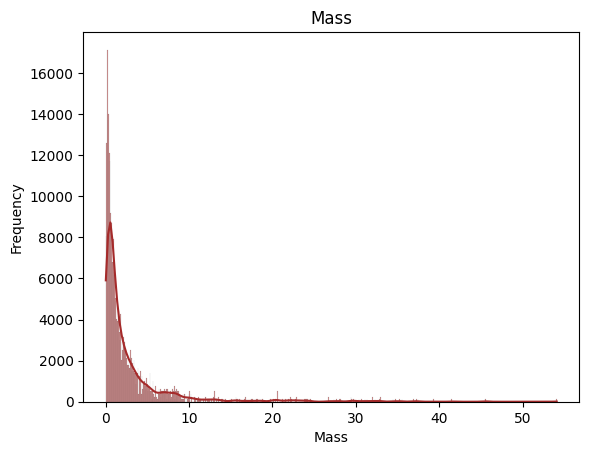

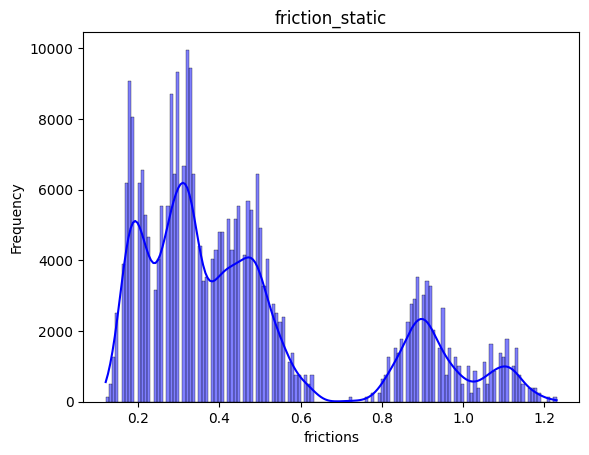

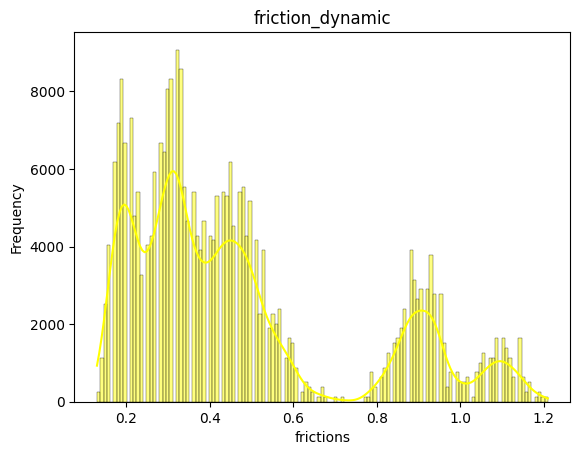

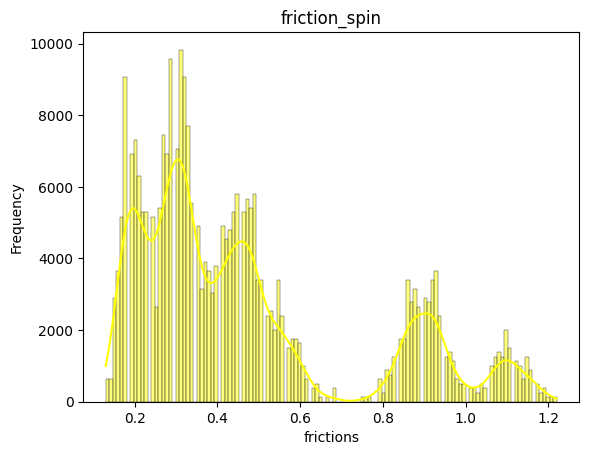

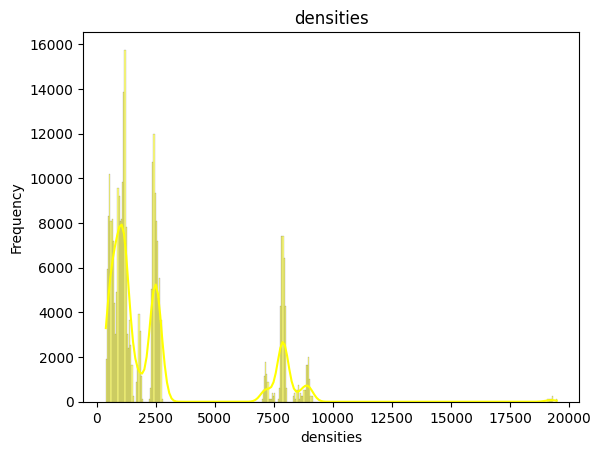

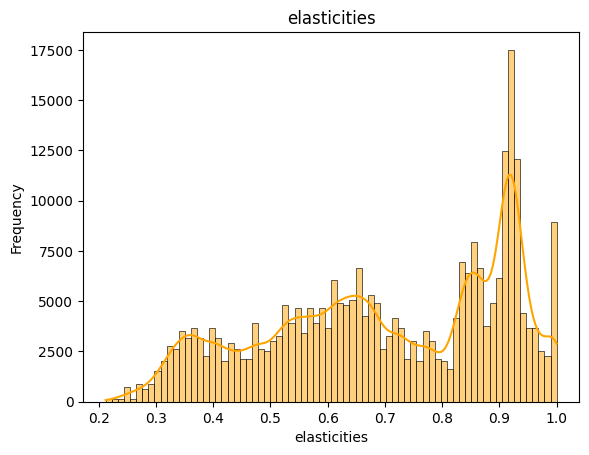

/var/folders/bf/x4w27yrx4md7qs_x4kjctl6r0000gn/T/ipykernel_37164/1450617809.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="shape", data=df_shapes, palette="viridis")


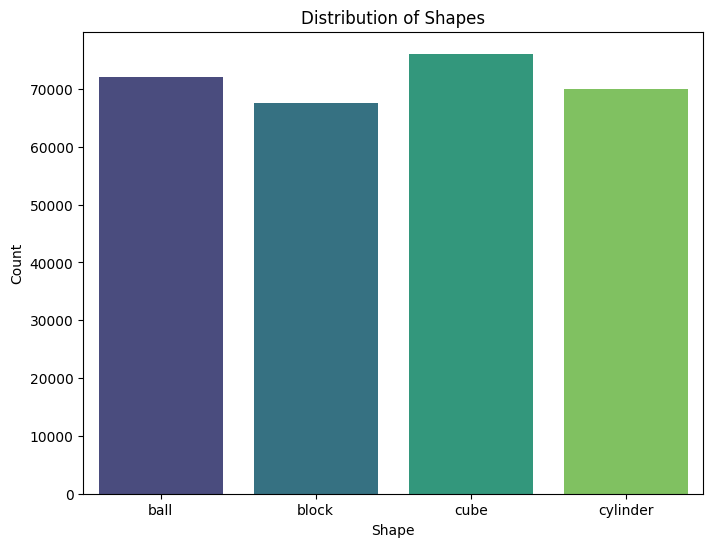

In [72]:
# plt.subplot(1, 2, 1)
plot_distribution(masses, "Mass", "Frequency", "Mass")
# plt.subplot(1, 2, 2)
# plt.tight_layout()
plot_distribution(friction_static, "friction_static", "Frequency", "frictions")
plot_distribution(friction_dynamic, "friction_dynamic", "Frequency", "frictions")
plot_distribution(friction_spin, "friction_spin", "Frequency", "frictions")
plot_distribution(densities, "densities", "Frequency", "densities")
plot_distribution(elasticities, "elasticities", "Frequency", "elasticities")
plot_shapes_distribution(shapes)


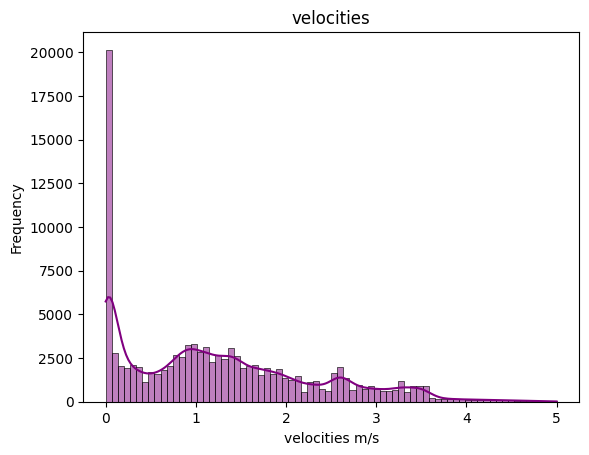

In [136]:
velocities_1 = list(filter(lambda v: round(v, 3) > 0, velocities))

plot_distribution(velocities_1, "velocities", "Frequency", "velocities m/s")
# plot_distribution(accelerations, "accelerations", "Frequency", "accelerations", kde=False)

97163 4601


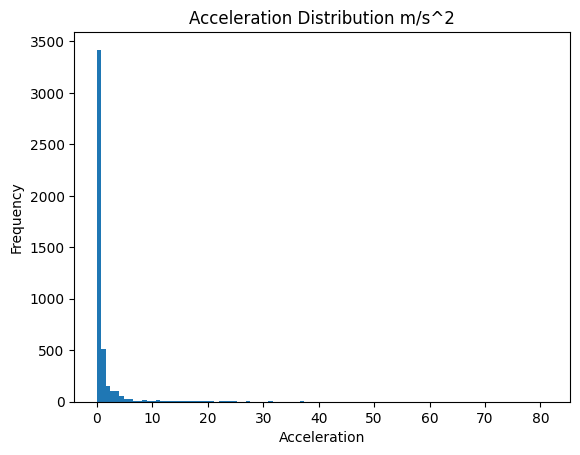

In [138]:
filtered_accelerations = [a for a in accelerations if  round(a, 3) > 0]
print(len(accelerations), len(filtered_accelerations))


plt.hist(filtered_accelerations, bins=100)
plt.title("Acceleration Distribution m/s^2")
plt.xlabel("Acceleration")
plt.ylabel("Frequency")
plt.show()


In [73]:

def analyze_data(extracted_features, use_correlation=False, scale_data=False):
    data = {k: v for k, v in extracted_features.items() if v}
    # print(data)
    max_length = max(len(data[key]) for key in data)
    # print("max_length", max_length)
    # Pad shorter lists with NaN to match the maximum length
    for key in data:
        # print("key", key)
        # print(len(data[key]))
        # print(data[key][-10:])
        if len(data[key]) < max_length:
            # print(len(data[key]))
            # data[key].extend(data[key] * (max_length - len(data[key])))
            while len(data[key]) < max_length:
                data[key].append(np.nan)


    df = pd.DataFrame(data)
    df = df.dropna() 

    # if scale_data:
    #     scaler = StandardScaler()
    #     df = pd.DataFrame(scaler.fit_transform(df), columns = df.columns) # Scale data

    if use_correlation:
        matrix = df.corr(method='pearson') 
        title = 'Correlation Matrix of Physical Properties'
    else:
        matrix = df.cov()
        title = 'Covariance Matrix of Physical Properties'

    plt.figure(figsize=(12, 10))
    sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(title)
    plt.show()



In [74]:
obj_features = extract_features(data)
for k, i in obj_features.items():
    print(k, len(i))

masses 285768
velocities 285768
accelerations 285768
angular_velocities 285768
angular_accelerations 285768
friction_static 285768
friction_dynamic 285768
friction_spin 285768
densities 285768
elasticities 285768
shapes 285768


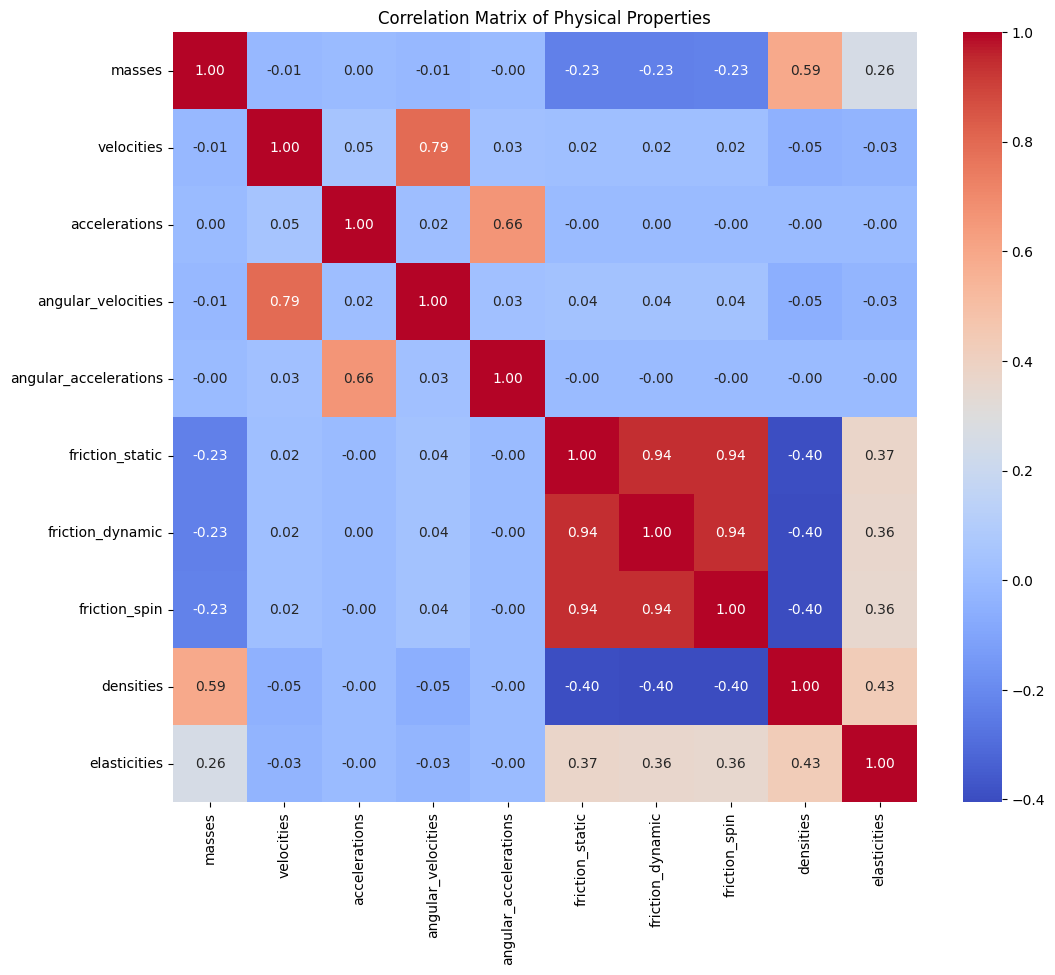

In [75]:
obj_features = extract_features(data)
del obj_features["shapes"]
world_features = extract_world_features(data)
analyze_data(obj_features, use_correlation=True, scale_data=True)  
# analyze_data(world_features, use_correlation=True, scale_data=True)  

### Video analysis

In [151]:
directory = 'generated'
data = load_data(directory)

['135', '307', '61', '95', '338', '300', '132', '59', '92', '66', '336', '104', '309', '50', '68', '103', '331', '57', '168', '391', '365', '157', '150', '362', '396', '159', '32', '166', '354', '192', '398', '35', '195', '353', '161', '330', '102', '69', '56', '105', '337', '51', '308', '58', '133', '301', '67', '93', '306', '134', '94', '339', '60', '399', '34', '160', '352', '194', '33', '158', '193', '355', '167', '397', '363', '151', '169', '156', '364', '390', '216', '440', '229', '447', '211', '478', '227', '471', '485', '218', '.DS_Store', '482', '476', '220', '449', '280', '422', '274', '273', '425', '287', '413', '245', '289', '242', '414', '477', '221', '483', '448', '484', '226', '470', '219', '446', '210', '479', '217', '441', '228', '288', '243', '415', '412', '244', '286', '272', '424', '423', '275', '281', '257', '401', '268', '406', '250', '439', '292', '266', '430', '259', '437', '261', '295', '408', '463', '235', '497', '490', '232', '464', '499', '452', '204', '203'

In [5]:
df = data[5]
frames = df.get("frames", {})
objects = df.get("objects", {})

In [153]:
object_ids = list(frames[0]["objects"].keys())
object_ids

['geom_obj1', 'geom_obj0', 'geom_obj2']

In [154]:
velocities = {obj_id: [] for obj_id in object_ids}

for frame in frames:
    for obj_id in object_ids:
        vel = frame["objects"].get(obj_id, {}).get("velocity", [0, 0, 0])
        velocities[obj_id].append(np.linalg.norm(vel))


velocity_df = pd.DataFrame(velocities)
velocity_df

,geom_obj1,geom_obj0,geom_obj2
0,1.026689,4.905000e-03,4.905000e-03
1,0.805216,9.423004e-04,4.407690e-03
2,0.730604,3.480230e-04,1.800171e-03
3,0.729346,9.232307e-05,4.739609e-04
4,0.729332,2.284663e-05,1.165892e-04
...,...,...,...
121,0.729333,3.774924e-15,4.293309e-07
122,0.729333,3.771819e-15,1.479415e-07
123,0.729333,3.771630e-15,4.366547e-08
124,0.729333,3.770046e-15,1.849486e-07


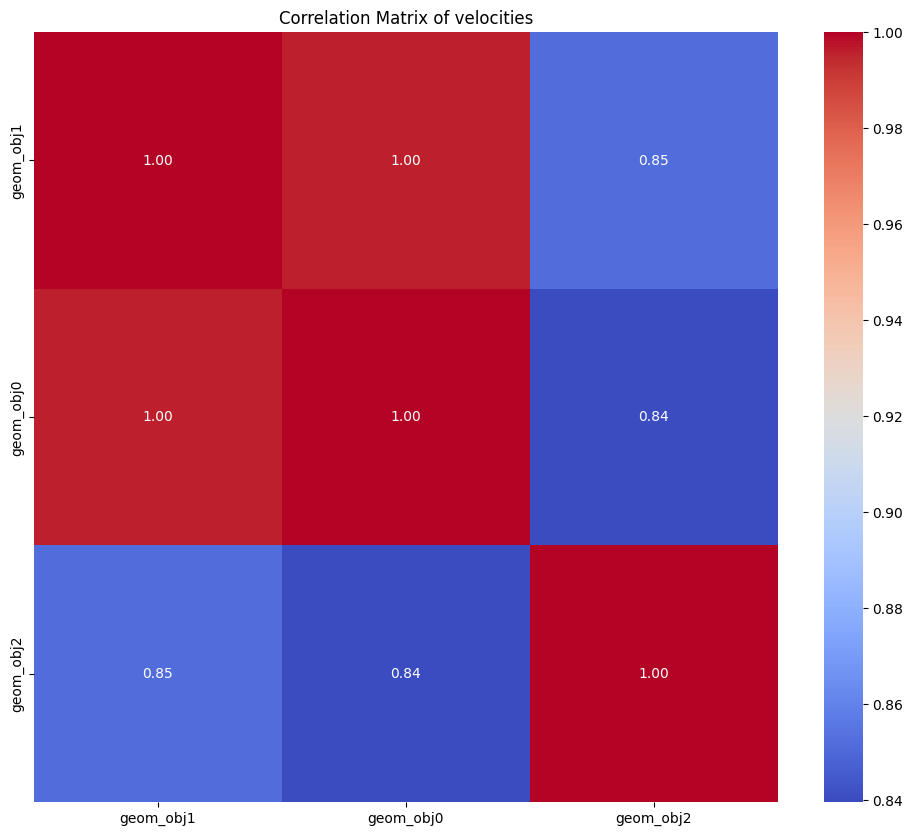

In [155]:
matrix = velocity_df.corr(method='pearson') 
title = 'Correlation Matrix of velocities'

plt.figure(figsize=(12, 10))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title(title)
plt.show()

 Strong positive correlation can point out that elements are being influenced by the same factors - friction, collisions.
 
 Negative correlation can indicate that it's moving in opposite direction or influenced by different factors.
 

In [156]:
df_objects = pd.DataFrame(objects)
# df_objects.iloc[0, :]
# object_ids

In [246]:
df_combined = velocity_df.melt(var_name="id", value_name="velocity")
df_combined = df_combined.merge(df_objects, on="id")

df_combined.head()

,id,velocity_x,shape,material,material_shininess,dimensions,mass,density,elasticity,friction,...,angular_velocity,mode,init_possition_x,init_possition_y,collision_radius,volume,base_z,geom_type,size_str,geom_id
0,geom_obj1,1.026689,ball,rubber,0,{'radius': 0.09143178205456053},3.628811,1133.4025,0.892,0.99 0.89 0.85,...,"[0.5284400200316961, -0.5808332022836662, 0.84...",offset,0.941519,-1.287263,1.27542,0.003202,0.091432,sphere,0.0914,2
1,geom_obj1,0.805216,ball,rubber,0,{'radius': 0.09143178205456053},3.628811,1133.4025,0.892,0.99 0.89 0.85,...,"[0.5284400200316961, -0.5808332022836662, 0.84...",offset,0.941519,-1.287263,1.27542,0.003202,0.091432,sphere,0.0914,2
2,geom_obj1,0.730604,ball,rubber,0,{'radius': 0.09143178205456053},3.628811,1133.4025,0.892,0.99 0.89 0.85,...,"[0.5284400200316961, -0.5808332022836662, 0.84...",offset,0.941519,-1.287263,1.27542,0.003202,0.091432,sphere,0.0914,2
3,geom_obj1,0.729346,ball,rubber,0,{'radius': 0.09143178205456053},3.628811,1133.4025,0.892,0.99 0.89 0.85,...,"[0.5284400200316961, -0.5808332022836662, 0.84...",offset,0.941519,-1.287263,1.27542,0.003202,0.091432,sphere,0.0914,2
4,geom_obj1,0.729332,ball,rubber,0,{'radius': 0.09143178205456053},3.628811,1133.4025,0.892,0.99 0.89 0.85,...,"[0.5284400200316961, -0.5808332022836662, 0.84...",offset,0.941519,-1.287263,1.27542,0.003202,0.091432,sphere,0.0914,2


In [158]:
df_combined.iloc[0,:]

id                                                            geom_obj1
velocity_x                                                     1.026689
shape                                                              ball
material                                                         rubber
material_shininess                                                    0
dimensions                              {'radius': 0.09143178205456053}
mass                                                           3.628811
density                                                       1133.4025
elasticity                                                        0.892
friction                                                 0.99 0.89 0.85
visual                {'rgba': '0.000 0.600 0.600 1.000', 'specular'...
velocity_y            [-0.6048333375874408, 0.8269402261929351, 0.07...
angular_velocity      [0.5284400200316961, -0.5808332022836662, 0.84...
mode                                                            

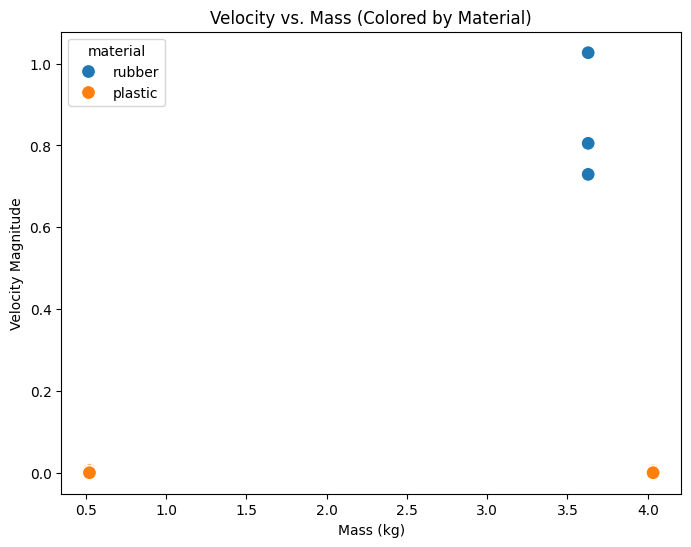

In [247]:
# velocity vs mass
plt.figure(figsize=(8, 6))
# vel = np.mean(df_combined["velocity_x"])
# df_combined["vel_arg"] = vel
sns.scatterplot(x="mass", y="velocity_x", hue="material", data=df_combined, s=100)
plt.title("Velocity vs. Mass (Colored by Material)")
plt.xlabel("Mass (kg)")
plt.ylabel("Velocity Magnitude")
plt.show()

Heavier objects may have lower velocity due to friction and inertia


In [166]:
df_combined["friction"].iloc[0].split(' ')

['0.99', '0.89', '0.85']

In [249]:
def con(k):
    list_frictions = k.split(' ')
    list_frictions = [float(f) for f in list_frictions]
    return np.mean(list_frictions)
    
df_combined["avg_friction"] = df_combined["friction"].apply(con)

df_combined

,id,velocity_x,shape,material,material_shininess,dimensions,mass,density,elasticity,friction,...,mode,init_possition_x,init_possition_y,collision_radius,volume,base_z,geom_type,size_str,geom_id,avg_friction
0,geom_obj1,1.026689e+00,ball,rubber,0,{'radius': 0.09143178205456053},3.628811,1133.402500,0.892,0.99 0.89 0.85,...,offset,0.941519,-1.287263,1.275420,0.003202,0.091432,sphere,0.0914,2,0.910000
1,geom_obj1,8.052159e-01,ball,rubber,0,{'radius': 0.09143178205456053},3.628811,1133.402500,0.892,0.99 0.89 0.85,...,offset,0.941519,-1.287263,1.275420,0.003202,0.091432,sphere,0.0914,2,0.910000
2,geom_obj1,7.306037e-01,ball,rubber,0,{'radius': 0.09143178205456053},3.628811,1133.402500,0.892,0.99 0.89 0.85,...,offset,0.941519,-1.287263,1.275420,0.003202,0.091432,sphere,0.0914,2,0.910000
3,geom_obj1,7.293459e-01,ball,rubber,0,{'radius': 0.09143178205456053},3.628811,1133.402500,0.892,0.99 0.89 0.85,...,offset,0.941519,-1.287263,1.275420,0.003202,0.091432,sphere,0.0914,2,0.910000
4,geom_obj1,7.293324e-01,ball,rubber,0,{'radius': 0.09143178205456053},3.628811,1133.402500,0.892,0.99 0.89 0.85,...,offset,0.941519,-1.287263,1.275420,0.003202,0.091432,sphere,0.0914,2,0.910000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,geom_obj2,4.293309e-07,cylinder,plastic,5,"{'radius': 0.07811247322673802, 'height': 0.11...",4.033227,1826.682732,0.656,0.39 0.33 0.23,...,stationary,0.034613,0.799182,1.040249,0.002208,0.057593,cylinder,0.0781 0.0576,3,0.316667
374,geom_obj2,1.479415e-07,cylinder,plastic,5,"{'radius': 0.07811247322673802, 'height': 0.11...",4.033227,1826.682732,0.656,0.39 0.33 0.23,...,stationary,0.034613,0.799182,1.040249,0.002208,0.057593,cylinder,0.0781 0.0576,3,0.316667
375,geom_obj2,4.366547e-08,cylinder,plastic,5,"{'radius': 0.07811247322673802, 'height': 0.11...",4.033227,1826.682732,0.656,0.39 0.33 0.23,...,stationary,0.034613,0.799182,1.040249,0.002208,0.057593,cylinder,0.0781 0.0576,3,0.316667
376,geom_obj2,1.849486e-07,cylinder,plastic,5,"{'radius': 0.07811247322673802, 'height': 0.11...",4.033227,1826.682732,0.656,0.39 0.33 0.23,...,stationary,0.034613,0.799182,1.040249,0.002208,0.057593,cylinder,0.0781 0.0576,3,0.316667


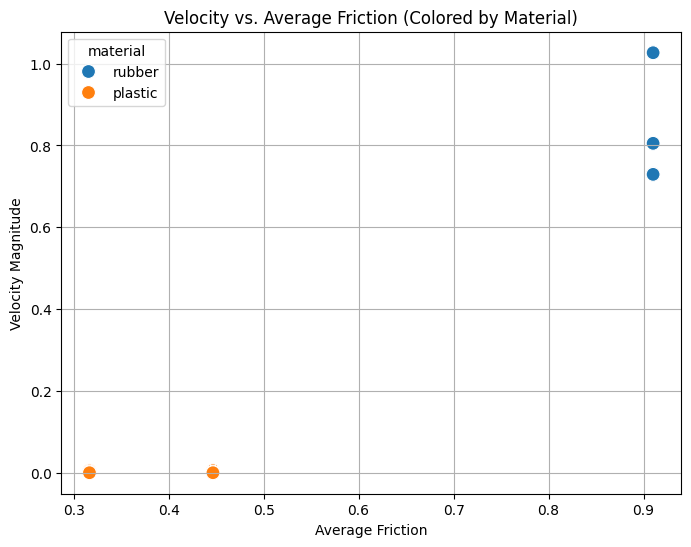

In [250]:
# average friction 
# df_combined["avg_friction"] = df_combined["friction"].apply(lambda f: np.mean(f))

# Plot velocity vs. average friction
plt.figure(figsize=(8, 6))
sns.scatterplot(x="avg_friction", y="velocity_x", hue="material", data=df_combined, s=100)
plt.title("Velocity vs. Average Friction (Colored by Material)")
plt.xlabel("Average Friction")
plt.ylabel("Velocity Magnitude")
plt.grid()
plt.show()

In [251]:
from scipy.stats import pearsonr


corr, p_value = pearsonr(df_combined["velocity_x"], df_combined["avg_friction"])
print(f"Velocity vs avg friction: {corr:.2f}, P-value: {p_value:.4f}")


Velocity vs avg friction: 0.98, P-value: 0.0000


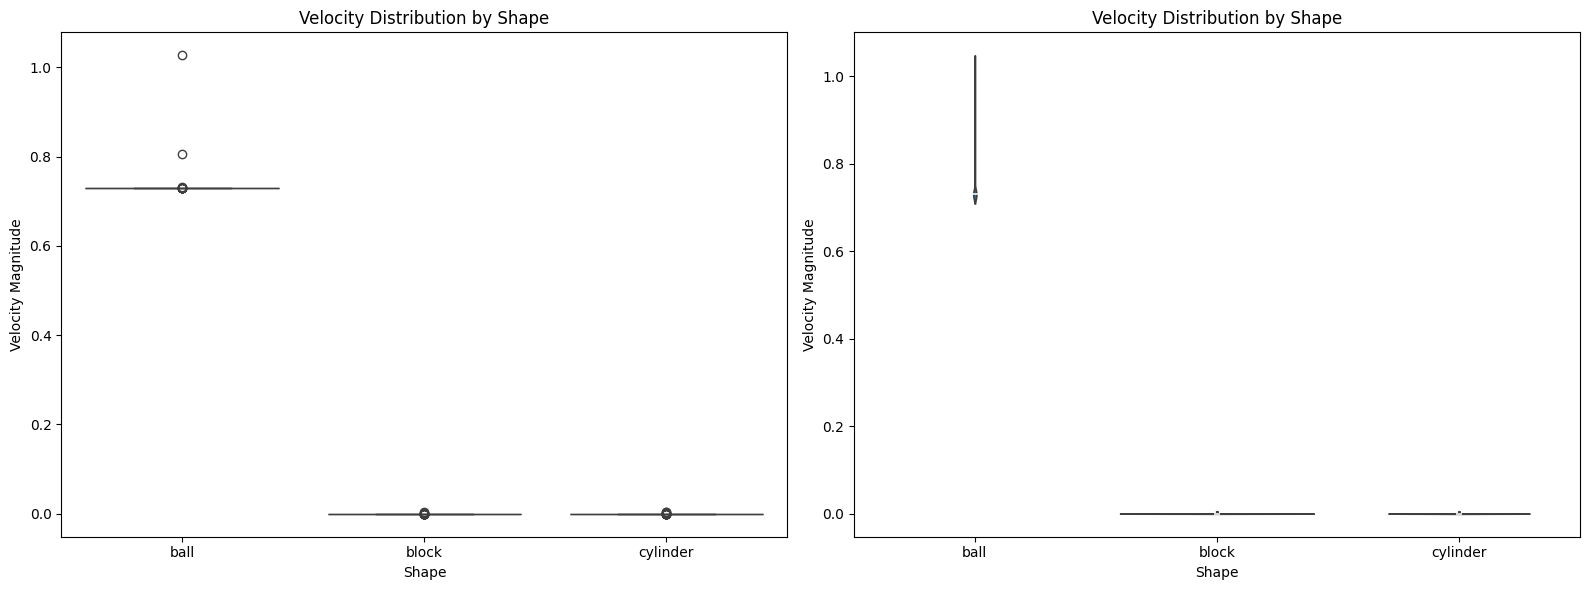

In [252]:
# # velocity dist shape
# plt.figure(figsize=(8, 6))
# sns.boxplot(x="shape", y="velocity_x", data=df_combined)
# sns.violinplot(x="shape", y="velocity_x", data=df_combined)
# plt.title("Velocity Distribution by Shape")
# plt.xlabel("Shape")
# plt.ylabel("Velocity Magnitude")
# plt.show()



plt.figure(figsize=(16, 6)) 

plt.subplot(1, 2, 1)
sns.boxplot(x="shape", y="velocity_x", data=df_combined)
plt.title("Velocity Distribution by Shape")
plt.xlabel("Shape")
plt.ylabel("Velocity Magnitude")

plt.subplot(1, 2, 2) 
sns.violinplot(x="shape", y="velocity_x", data=df_combined)
plt.title("Velocity Distribution by Shape")
plt.xlabel("Shape")
plt.ylabel("Velocity Magnitude")

plt.tight_layout()  
plt.show()

In [253]:
collision_counts = {obj_id: 0 for obj_id in object_ids}

for frame in frames:
    for obj_id in object_ids:
        taxonomy = frame["objects"].get(obj_id, {}).get("taxonomy", [])
        for event in taxonomy:
            if event.get("category") == "Interaction Events" and event.get("subcategory") == "Collisions":
                collision_counts[obj_id] += 1


In [256]:
collision_df = pd.DataFrame(list(collision_counts.items()), columns=["id", "collision_count"])
collision_df

,id,collision_count
0,geom_obj1,0
1,geom_obj0,0
2,geom_obj2,0


In [257]:
average_velocity = velocity_df.mean().reset_index()
average_velocity.columns = ["id", "average_velocity"]

df_analysis = average_velocity.merge(collision_df, on="id")
df_analysis["num_objects"] = len(object_ids)
df_analysis

,id,average_velocity,collision_count,num_objects
0,geom_obj1,0.732306,0,3
1,geom_obj0,0.000050,0,3
2,geom_obj2,0.000093,0,3


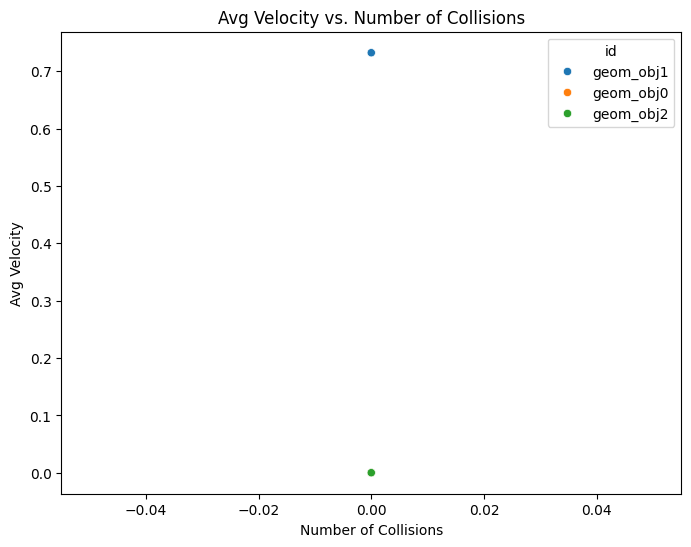

In [258]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="collision_count", y="average_velocity", data=df_analysis, hue="id")
plt.title("Avg Velocity vs. Number of Collisions")
plt.xlabel("Number of Collisions")
plt.ylabel("Avg Velocity")
plt.show()

In [259]:
from scipy.stats import pearsonr


corr, p_value = pearsonr(df_analysis["collision_count"], df_analysis["average_velocity"])
print(f"Velocity vs collision count: {corr:.2f}, P-value: {p_value:.4f}")


Velocity vs collision count: nan, P-value: nan


/var/folders/bf/x4w27yrx4md7qs_x4kjctl6r0000gn/T/ipykernel_58697/2819567888.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(df_analysis["collision_count"], df_analysis["average_velocity"])


In [65]:
df_analysis

,id,average_velocity,collision_count,num_objects
0,geom_obj6,0.031560,0,7
1,geom_obj0,0.012133,0,7
2,geom_obj5,0.282605,0,7
3,geom_obj4,0.404001,5,7
4,geom_obj2,0.287530,5,7
5,geom_obj1,0.100896,0,7
6,geom_obj3,0.003846,0,7


In [260]:
velocity_stats = velocity_df.agg(["mean", "std", "min", "max"]).T.reset_index()
velocity_stats.columns = ["id", "mean_velocity", "std_velocity", "min_velocity", "max_velocity"]

df_analysis = velocity_stats.merge(collision_df, on="id")
df_analysis

,id,mean_velocity,std_velocity,min_velocity,max_velocity,collision_count
0,geom_obj1,0.732306,0.027286,7.293324e-01,1.026689,0
1,geom_obj0,0.000050,0.000445,3.734433e-15,0.004905,0
2,geom_obj2,0.000093,0.000606,9.236951e-10,0.004905,0


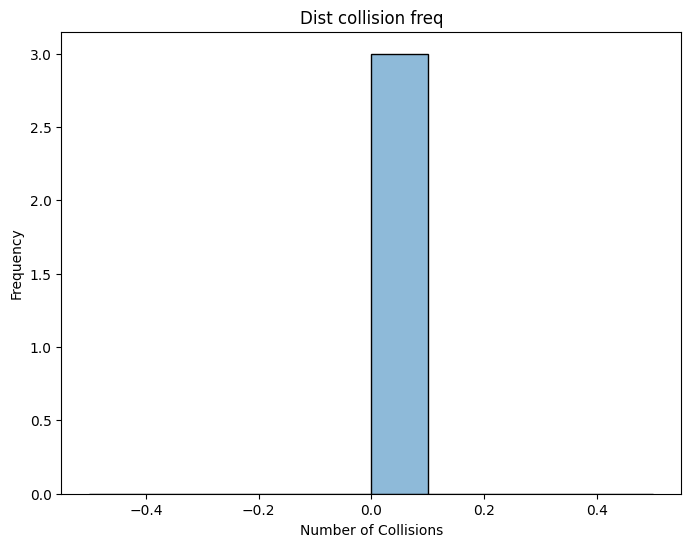

In [261]:
plt.figure(figsize=(8, 6))
sns.histplot(df_analysis["collision_count"], bins=10, kde=True)
plt.title("Dist collision freq")
plt.xlabel("Number of Collisions")
plt.ylabel("Frequency")
plt.show()

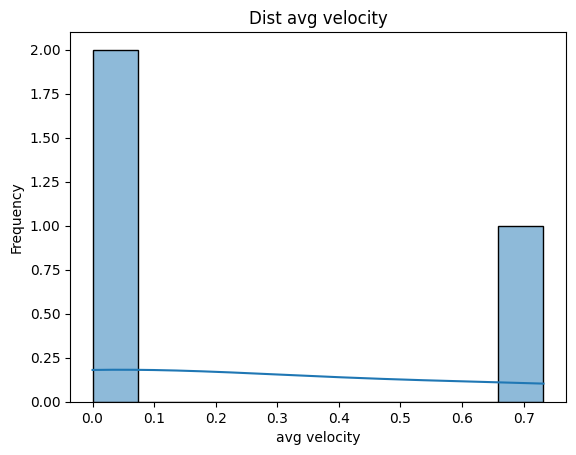

In [262]:
sns.histplot(df_analysis["mean_velocity"], bins=10, kde=True)
plt.title("Dist avg velocity")
plt.xlabel("avg velocity")
plt.ylabel("Frequency")
plt.show()

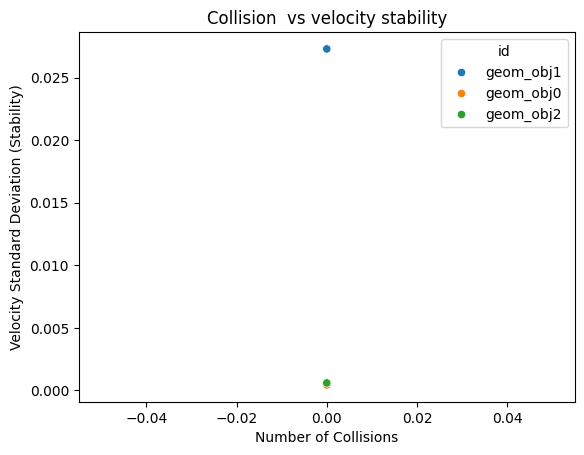

In [263]:
sns.scatterplot(x="collision_count", y="std_velocity", data=df_analysis, hue="id")
plt.title("Collision  vs velocity stability")
plt.xlabel("Number of Collisions")
plt.ylabel("Velocity Standard Deviation (Stability)")
plt.show()

In [264]:
corr, p_value = pearsonr(df_analysis["collision_count"], df_analysis["std_velocity"])
print(f"correlation xollisions vs vel stability: {corr:.2f}, P-value: {p_value:.4f}")


correlation xollisions vs vel stability: nan, P-value: nan


/var/folders/bf/x4w27yrx4md7qs_x4kjctl6r0000gn/T/ipykernel_58697/2557740765.py:1: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(df_analysis["collision_count"], df_analysis["std_velocity"])


In [179]:
def analyze_video(data):
    frames = data.get("frames", {})
    objects = data.get("objects", {})

    object_ids = list(frames[0]["objects"].keys())
    velocities = {obj_id: [] for obj_id in object_ids}

    for frame in frames:
        for obj_id in object_ids:
            vel = frame["objects"].get(obj_id, {}).get("velocity", [0, 0, 0])
            velocities[obj_id].append(np.linalg.norm(vel))

    velocity_df = pd.DataFrame(velocities)
    df_objects = pd.DataFrame(objects)
    df_combined = velocity_df.melt(var_name="id", value_name="velocity")
    df_combined = df_combined.merge(df_objects, on="id")

    # df_combined["avg_friction"] = df_combined["friction"].apply(lambda f: np.mean(f))

    collision_counts = {obj_id: 0 for obj_id in object_ids}
    for frame in frames:
        for obj_id in object_ids:
            taxonomy = frame["objects"].get(obj_id, {}).get("taxonomy", [])
            for event in taxonomy:
                if event.get("category") == "Interaction Events" and event.get("subcategory") == "Collisions":
                    collision_counts[obj_id] += 1

    collision_df = pd.DataFrame(list(collision_counts.items()), columns=["id", "collision_count"])
    average_velocity = velocity_df.mean().reset_index()
    average_velocity.columns = ["id", "average_velocity"]
    df_analysis = average_velocity.merge(collision_df, on="id")
    df_analysis["num_objects"] = len(object_ids)

    velocity_stats = velocity_df.agg(["mean", "std", "min", "max"]).T.reset_index()
    velocity_stats.columns = ["id", "mean_velocity", "std_velocity", "min_velocity", "max_velocity"]
    df_analysis = velocity_stats.merge(collision_df, on="id")

    return df_analysis

def analyze_multiple_videos(all_data):
    all_results = []

    for data in all_data:
        df_analysis = analyze_video(data)
        all_results.append(df_analysis)

    combined_results = pd.concat(all_results, ignore_index=True)
    return combined_results


In [180]:
comb_res = analyze_multiple_videos(data)

In [181]:
comb_res

,id,mean_velocity,std_velocity,min_velocity,max_velocity,collision_count
0,geom_obj3,1.290482,0.060451,1.280309e+00,1.772506,0
1,geom_obj1,0.408367,1.117144,1.988155e-15,4.952635,0
2,geom_obj0,1.012851,0.041675,1.007942e+00,1.441356,0
3,geom_obj2,0.173469,0.616718,4.645657e-15,3.525838,0
4,geom_obj4,0.119753,0.356861,3.712590e-15,1.797337,0
...,...,...,...,...,...,...
2286,geom_obj0,1.403766,0.062872,1.395504e+00,1.983606,0
2287,geom_obj2,0.000061,0.000470,3.633390e-15,0.004905,0
2288,geom_obj1,0.000113,0.000719,7.622935e-12,0.005985,0
2289,geom_obj0,0.020726,0.001422,4.905000e-03,0.021488,0


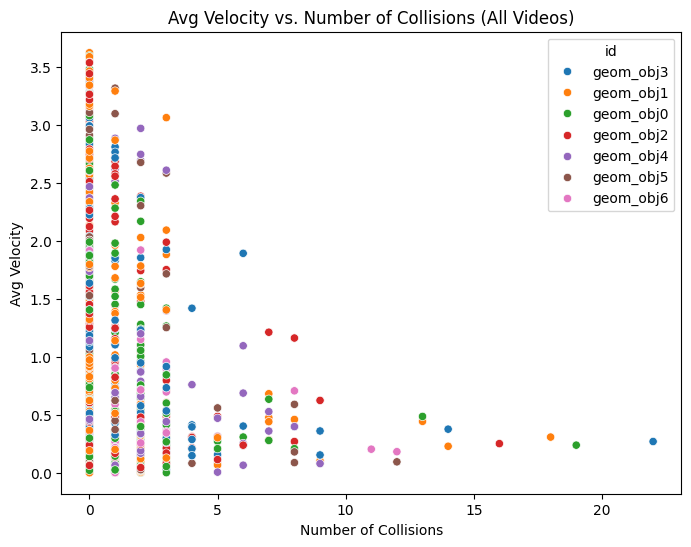

In [182]:


plt.figure(figsize=(8, 6))
sns.scatterplot(x="collision_count", y="mean_velocity", data=comb_res, hue="id")
plt.title("Avg Velocity vs. Number of Collisions (All Videos)")
plt.xlabel("Number of Collisions")
plt.ylabel("Avg Velocity")
plt.show()


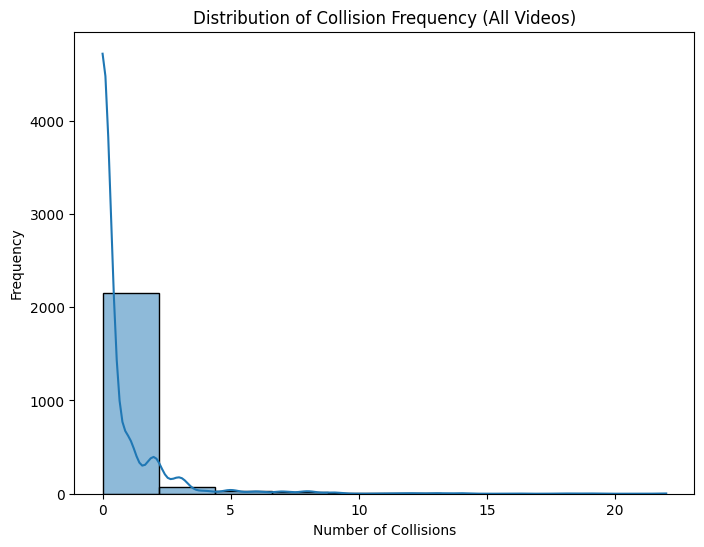

In [183]:

plt.figure(figsize=(8, 6))
sns.histplot(comb_res["collision_count"], bins=10, kde=True)
plt.title("Distribution of Collision Frequency (All Videos)")
plt.xlabel("Number of Collisions")
plt.ylabel("Frequency")
plt.show()


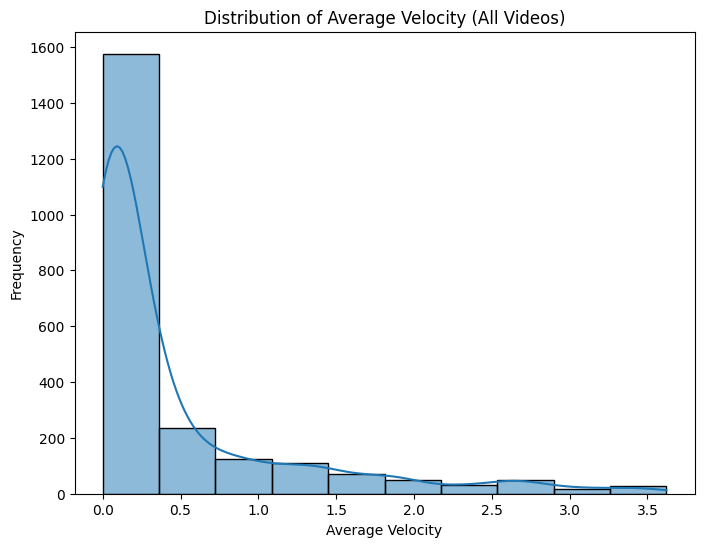

In [184]:

plt.figure(figsize=(8, 6))
sns.histplot(comb_res["mean_velocity"], bins=10, kde=True)
plt.title("Distribution of Average Velocity (All Videos)")
plt.xlabel("Average Velocity")
plt.ylabel("Frequency")
plt.show()


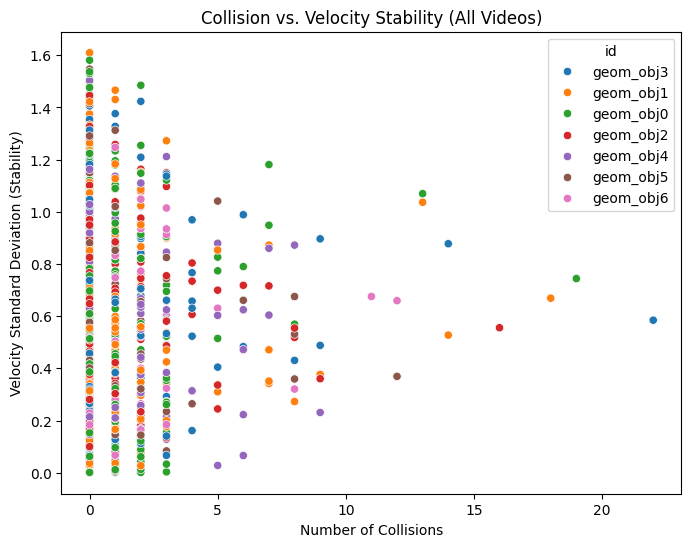

Correlation between collisions and velocity stability: 0.18, P-value: 0.0000


In [185]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x="collision_count", y="std_velocity", data=comb_res, hue="id")
plt.title("Collision vs. Velocity Stability (All Videos)")
plt.xlabel("Number of Collisions")
plt.ylabel("Velocity Standard Deviation (Stability)")
plt.show()

corr, p_value = pearsonr(comb_res["collision_count"], comb_res["std_velocity"])
print(f"Correlation between collisions and velocity stability: {corr:.2f}, P-value: {p_value:.4f}")

In [40]:

def extract_time_series(data):
    frames = data.get("frames", {})
    objects = data.get("objects", {})

    objects_dict = {obj["id"]: obj for obj in objects}


    object_ids = list(frames[0]["objects"].keys())
    time_series_data = {obj_id: {"velocity": [], "angular_velocity": [], "acceleration": [], 
                                 # "friction": [], "mass": [],
                                } for obj_id in object_ids}

    prev_velocities = {obj_id: np.array([0, 0, 0]) for obj_id in object_ids}
    prev_time = frames[0]["time"]

    for frame in frames:
        current_time = frame["time"]
        dt = current_time - prev_time
        prev_time = current_time

        for obj_id in object_ids:
            obj_data = frame["objects"].get(obj_id, {})
    
            friction = objects_dict.get(obj_id, '').get("friction", "0 0 0").split(' ')
            friction = [float(f) for f in friction]
            # print("friction", friction)
            
            # time_series_data[obj_id]["friction"].append(np.mean(friction))
            # time_series_data[obj_id]["mass"].append(float(objects_dict.get(obj_id, '').get("mass", "0")))

            
            velocity = np.array(obj_data.get("velocity", [0, 0, 0]))
            angular_velocity = np.array(obj_data.get("angular_velocity", [0, 0, 0]))

            time_series_data[obj_id]["velocity"].append(np.linalg.norm(velocity))
            time_series_data[obj_id]["angular_velocity"].append(np.linalg.norm(angular_velocity))

            if dt > 0:
                acceleration = (velocity - prev_velocities[obj_id]) / dt
                time_series_data[obj_id]["acceleration"].append(np.linalg.norm(acceleration))
            else:
                time_series_data[obj_id]["acceleration"].append(0)

            prev_velocities[obj_id] = velocity

    return time_series_data

def create_correlation_matrix(time_series_data):
    df = pd.DataFrame()
    for obj_id, data in time_series_data.items():
        for param, values in data.items():
            df[f"{obj_id}_{param}"] = values

    correlation_matrix = df.corr(method='pearson')
    return correlation_matrix

def analyze_multiple_videos(all_data):
    correlation_matrices = []

    for data in all_data:
        time_series_data = extract_time_series(data)
        # print(time_series_data["geom_obj3"]["angular_velocity"])
        # print(time_series_data["geom_obj3"]["friction"])
        correlation_matrix = create_correlation_matrix(time_series_data)
        correlation_matrices.append(correlation_matrix)
        # break

    return correlation_matrices



In [41]:
# directory = 'generated'
# data = load_data(directory)
correlation_matrices = analyze_multiple_videos(data)

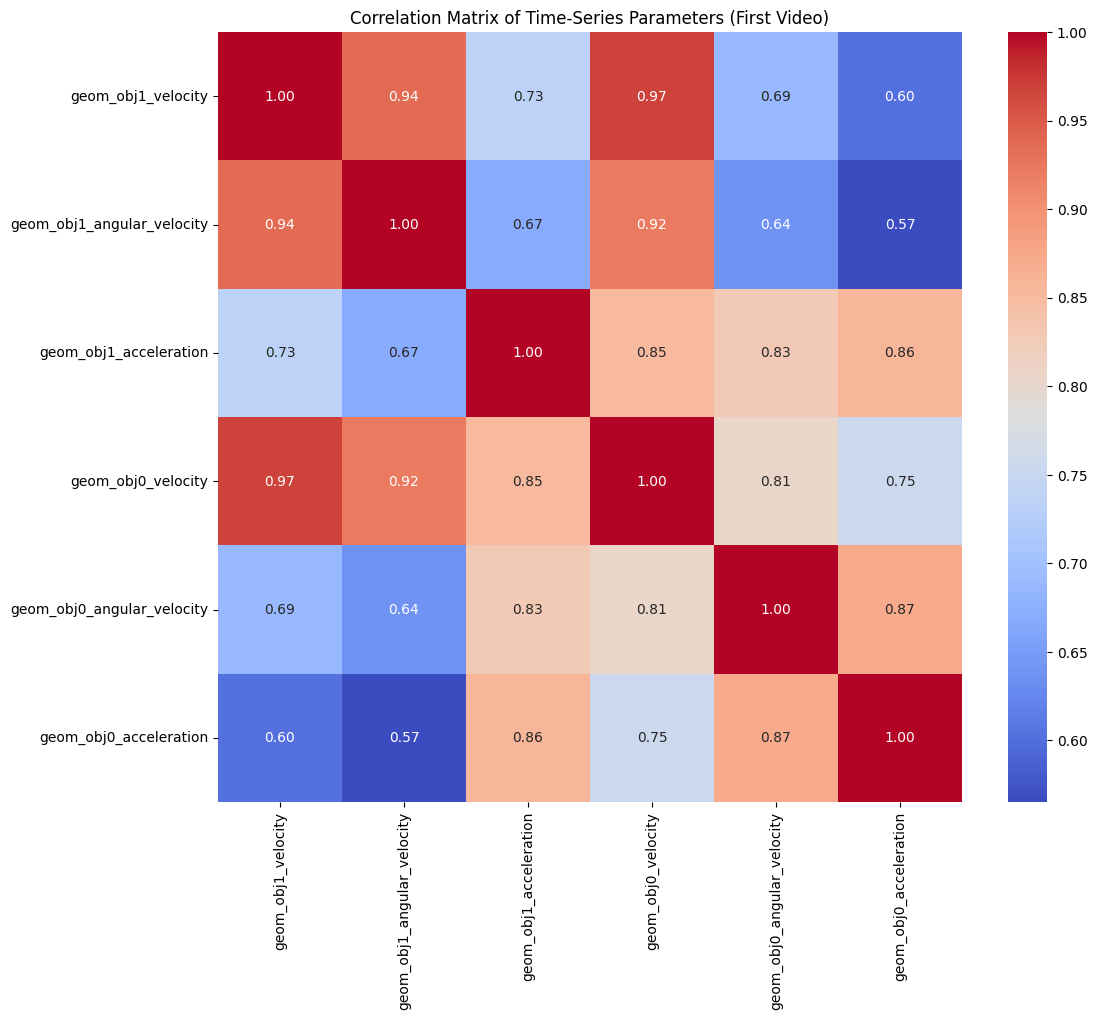

In [42]:

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrices[4], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Time-Series Parameters (First Video)")
plt.show()

In [35]:
correlation_matrices[4]

,geom_obj1_velocity,geom_obj1_angular_velocity,geom_obj1_acceleration,geom_obj0_velocity,geom_obj0_angular_velocity,geom_obj0_acceleration
geom_obj1_velocity,1.000000,0.937120,0.734774,0.968547,0.688162,0.602412
geom_obj1_angular_velocity,0.937120,1.000000,0.667883,0.921250,0.637197,0.565195
geom_obj1_acceleration,0.734774,0.667883,1.000000,0.852078,0.829218,0.858725
geom_obj0_velocity,0.968547,0.921250,0.852078,1.000000,0.806143,0.754313
geom_obj0_angular_velocity,0.688162,0.637197,0.829218,0.806143,1.000000,0.871989
geom_obj0_acceleration,0.602412,0.565195,0.858725,0.754313,0.871989,1.000000


In [64]:
def compute_corr(x, y):
    x = np.array(x)
    y = np.array(y)
    if len(x) < 2 or len(y) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(x, y)[0,1]

def comput_self_correlation(df, features):
    self_corrs = []
    object_ids = list(df.keys())
    
    for obj in object_ids:
        data = {feat: ts_data[obj].get(feat, []) for feat in features}
        df = pd.DataFrame(data)
        corr_matrix = df.corr(method='pearson')
        self_corrs.append(corr_matrix.values)
    # print('self_corrs', self_corrs)
    if self_corrs:
        self_avg = np.nanmean(np.array(self_corrs), axis=0)
    else:
        self_avg = np.full((len(features), len(features)), np.nan)
    
    self_corr_df = pd.DataFrame(self_avg, index=features, columns=features)

    return self_corr_df

def comput_cross_correlation(df, features):
    cross_corrs = []
    object_ids = list(ts_data.keys())
    n_objects = len(object_ids)
    
    for i in range(n_objects):
        for j in range(i+1, n_objects):
            matrix_ij = np.empty((len(features), len(features)))
            for a, feat_a in enumerate(features):
                for b, feat_b in enumerate(features):
                    x = ts_data[object_ids[i]].get(feat_a, [])
                    y = ts_data[object_ids[j]].get(feat_b, [])
                    matrix_ij[a, b] = compute_corr(x, y)
            cross_corrs.append(matrix_ij)
    
    if cross_corrs:
        cross_avg = np.nanmean(np.array(cross_corrs), axis=0)
    else:
        cross_avg = np.full((len(features), len(features)), np.nan)
    
    cross_corr_df = pd.DataFrame(cross_avg, index=features, columns=features)
    return cross_corr_df
    
def compute_self_and_cross_correlations(ts_data):
    features = ["velocity", "angular_velocity", "acceleration"]
                # , "friction", "mass"]
    # self_corrs = []
    # cross_corrs = []

    self_corr_df = comput_self_correlation(ts_data, features)
    cross_corr_df = comput_cross_correlation(ts_data, features)

    return self_corr_df, cross_corr_df



In [65]:
all_video_self = []
all_video_cross = []

for video_data in data:
    # self_corr, cross_corr = process_video_data(video_data)
    ts_data = extract_time_series(video_data)
    # print("ts_data", ts_data)
    self_corr, cross_corr = compute_self_and_cross_correlations(ts_data)
    all_video_self.append(self_corr)
    all_video_cross.append(cross_corr)
    # break


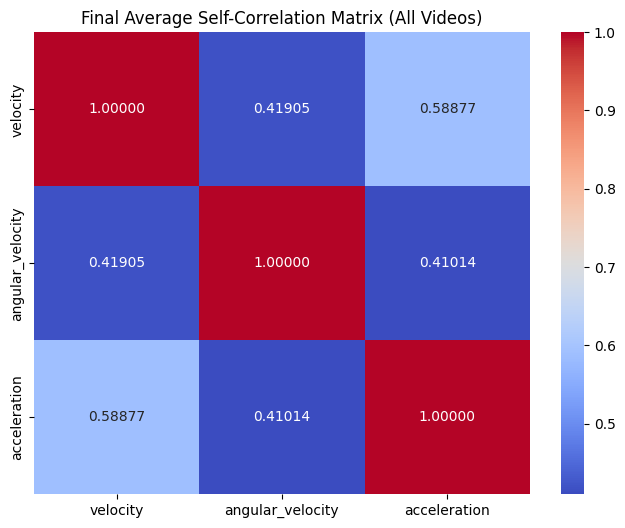

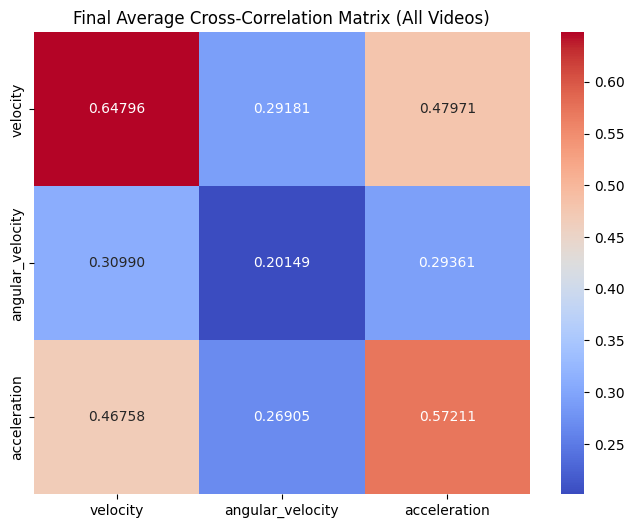

In [66]:

final_avg_self = np.nanmean(np.array(all_video_self), axis=0)
final_avg_cross = np.nanmean(np.array(all_video_cross), axis=0)

final_avg_self_df = pd.DataFrame(final_avg_self, index=["velocity", "angular_velocity", "acceleration"],
                                 columns=["velocity", "angular_velocity", "acceleration"])
final_avg_cross_df = pd.DataFrame(final_avg_cross, index=["velocity", "angular_velocity", "acceleration"],
                                  columns=["velocity", "angular_velocity", "acceleration"])

plt.figure(figsize=(8, 6))
sns.heatmap(final_avg_self_df, annot=True, cmap='coolwarm', fmt=".5f")
plt.title("Final Average Self-Correlation Matrix (All Videos)")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(final_avg_cross_df, annot=True, cmap='coolwarm', fmt=".5f")
plt.title("Final Average Cross-Correlation Matrix (All Videos)")
plt.show()
